<a href="https://colab.research.google.com/github/hanan-alshammary/project/blob/main/Final_project_HananDarwish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

caffeine's impact on sleep, stress, and health?

In [ ]:
#library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import svm
from sklearn.metrics import accuracy_score,precision_score, recall_score ,recall_score,f1_score,confusion_matrix,classification_report


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/dataset/synthetic_coffee_health_10000.csv')
df.head()

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1


In [ ]:
df.shape

(10000, 16)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
ID,0
Age,0
Gender,0
Country,0
Coffee_Intake,0
Caffeine_mg,0
Sleep_Hours,0
Sleep_Quality,0
BMI,0
Heart_Rate,0


In [ ]:
df.Health_Issues.value_counts()

,count
Health_Issues,
Mild,3579
Moderate,463
Severe,17


In [ ]:
df.dropna(axis=1,inplace=True)

In [ ]:
df.drop('ID',axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
Coffee_Intake,0
Caffeine_mg,0
Sleep_Hours,0
Sleep_Quality,0
BMI,0
Heart_Rate,0
Stress_Level,0


In [ ]:
df.describe()

,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


numerical features show normal distribution

In [ ]:
df.shape

(10000, 14)

1-Who has better Sleep Quality, females or males?

2-Which age group drinks the most coffee?

3-What is the relationship between Sleep Hours and Sleep Quality?

4-Who has a higher Stress Level, males or females?

5-Which occupation has the highest Stress Level?

6-What is the average caffeine intake for each sleep quality category?

In [ ]:
df[['Sleep_Quality', 'Sleep_Hours']].head()

,Sleep_Quality,Sleep_Hours
0,Good,7.5
1,Good,6.2
2,Fair,5.9
3,Good,7.3
4,Fair,5.3


In [ ]:
#1-Who has better Sleep Quality, females or males?
df['Healthy_Sleep'] = (df['Sleep_Hours'] >= 7) & (df['Sleep_Quality'] == 'Good')

Sleep_Quality more than 7 hours I can said Good sleep quality

Sleep_Quality less than 7 hours I can said poor sleep quality

In [ ]:
df['Healthy_Sleep'].value_counts()

,count
Healthy_Sleep,
False,7353
True,2647


In [ ]:
df['Healthy_Sleep'] = df['Healthy_Sleep'].map({
    False: 'Unhealthy',
    True: 'Healthy'
})

In [ ]:
df['Healthy_Sleep'].value_counts()

,count
Healthy_Sleep,
Unhealthy,7353
Healthy,2647


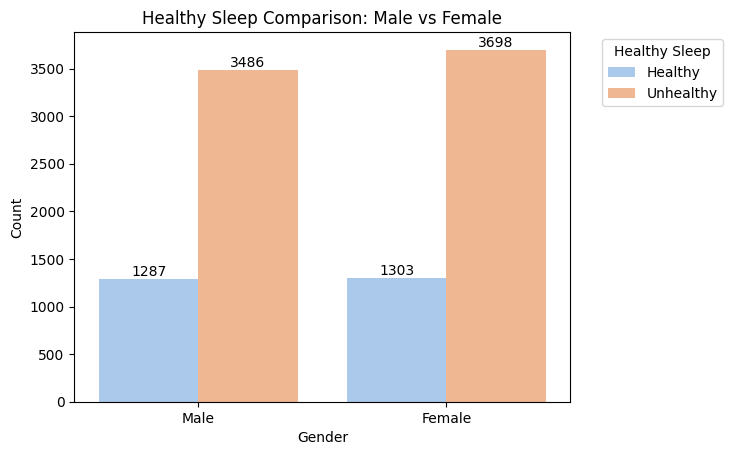

In [ ]:
df = df[df['Gender'] != 'Other']
ax = sns.countplot(data=df, x='Gender', hue='Healthy_Sleep', palette='pastel')

plt.title('Healthy Sleep Comparison: Male vs Female')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Healthy Sleep', bbox_to_anchor=(1.05, 1), loc='upper left')

for container in ax.containers:
    ax.bar_label(container)
plt.show()

In [ ]:
#2-Which age group drinks the most coffee?
df['Age_Group'] = pd.cut(df['Age'], bins=[17,30,45,84], labels=['Young','Middle_aged','Senior'])

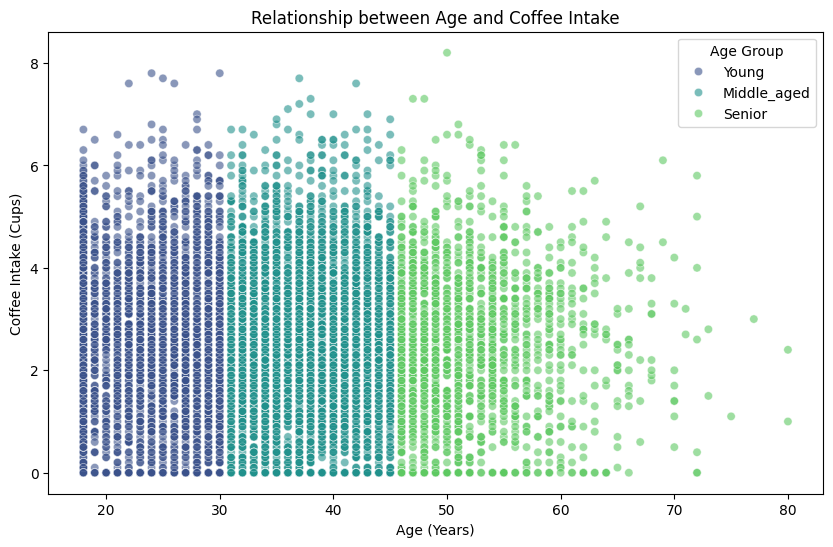

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Coffee_Intake', hue='Age_Group', palette='viridis', alpha=0.6)

plt.title('Relationship between Age and Coffee Intake')
plt.xlabel('Age (Years)')
plt.ylabel('Coffee Intake (Cups)')
plt.legend(title='Age Group')

plt.show()

Young (17-30): الاستهلاك متنوع جداً، يبدأ من 0 ويصل إلى قرابة 8 أكواب.

Middle_aged (30-45): استهلاك مستقر ومرتفع، حيث نرى "كتلة" كبيرة من النقاط تتركز فوق خط الـ 4 أكواب.

Senior (45-84): نلاحظ انخفاضاً تدريجياً؛ فبعد سن الـ 60، نادراً ما نجد شخصاً يتجاوز استهلاكه الـ 4 أو 5 أكواب.

In [ ]:
sleep_map = {
    'Poor': 0,
    'Fair': 1,
    'Good': 2,
    'Excellent': 3
}

df['Sleep_Quality'] = df['Sleep_Quality'].map(sleep_map)

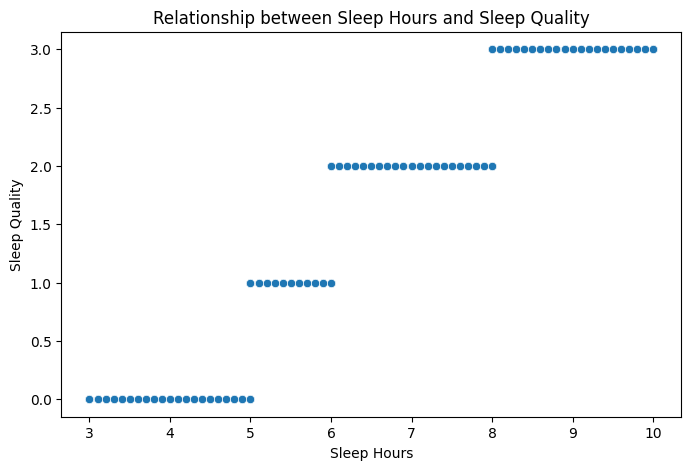

In [ ]:
#3-What is the relationship between Sleep Hours and Sleep Quality?
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Sleep_Hours',
    y='Sleep_Quality'
)

plt.title('Relationship between Sleep Hours and Sleep Quality')
plt.xlabel('Sleep Hours')
plt.ylabel('Sleep Quality')

plt.show()

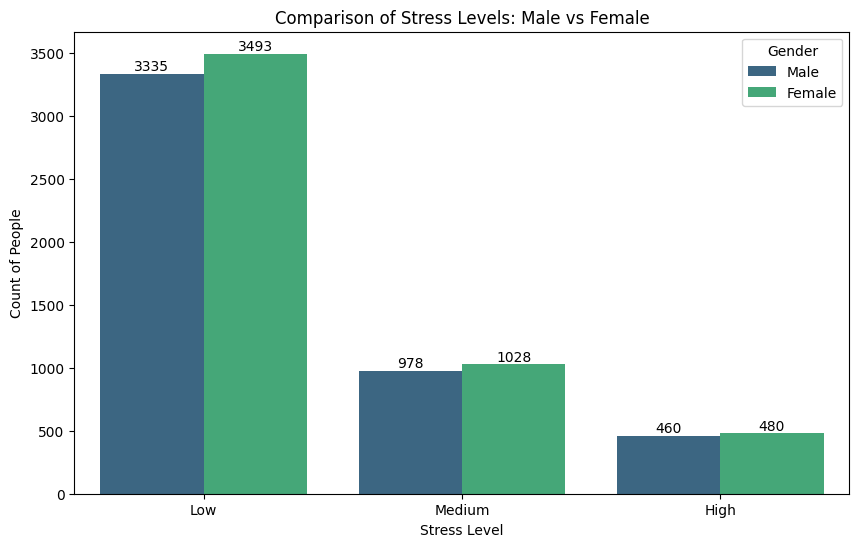

In [ ]:
#4-Who has a higher Stress Level, males or females?
df = df[df['Gender'] != 'Other']

plt.figure(figsize=(10,6))
ax = sns.countplot(data=df, x='Stress_Level', hue='Gender', palette='viridis', order=['Low', 'Medium', 'High'])

#number for easy to read
for container in ax.containers:
    ax.bar_label(container)

plt.title('Comparison of Stress Levels: Male vs Female')
plt.xlabel('Stress Level')
plt.ylabel('Count of People')
plt.show()

highest_stress Office
Occupation
Office        1.413742
Service       1.409139
Other         1.396084
Healthcare    1.388021
Student       1.380362
Name: Stress_Level, dtype: float64


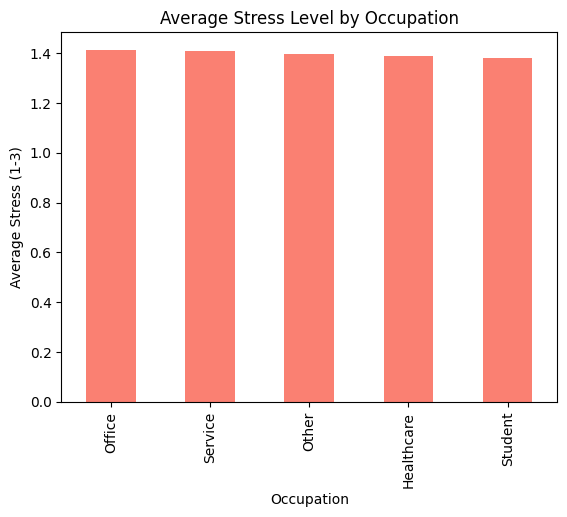

In [ ]:
#5-Which occupation has the highest Stress Level?

stress_mapping = {'Low': 1, 'Medium': 2, 'High': 3}
df['Stress_Level'] = df['Stress_Level'].map(stress_mapping)

# . حساب متوسط مستوى التوتر لكل مهنة
occupation_stress = df.groupby('Occupation')['Stress_Level'].mean().sort_values(ascending=False)

# . عرض النتيجة (أعلى مهنة في مستوى التوتر)
highest_stress_job = occupation_stress.idxmax()
highest_stress_value = occupation_stress.max()

print(f"highest_stress {highest_stress_job}")

print(occupation_stress)



occupation_stress.plot(kind='bar', color='salmon')
plt.title('Average Stress Level by Occupation')
plt.ylabel('Average Stress (1-3)')
plt.show()

 أن موظفي المكاتب (Office) هم الأكثر توتراً، وهذا الرسم يوضح أن الشباب في العمر هم الأكثر استهلاكاً، فهذا يفسر التداخل بين ضغوط العمل في بداية المسار المهني وزيادة الاعتماد على القهوة."

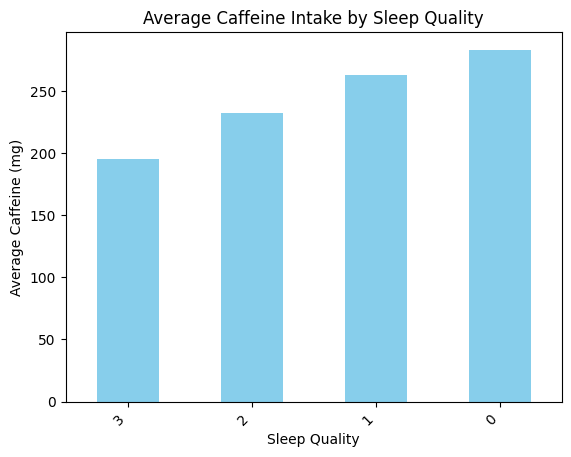

In [ ]:
#6-What is the average caffeine intake for each sleep quality category?
avg_caffeine_by_sleep = df.groupby('Sleep_Quality')['Caffeine_mg'].mean().sort_values(ascending=True)
avg_caffeine_by_sleep.plot(kind='bar', color='skyblue')
plt.xlabel('Sleep Quality')
plt.ylabel('Average Caffeine (mg)')
plt.xticks(rotation=45, ha='right')
plt.title('Average Caffeine Intake by Sleep Quality');

The Negative Effects of Coffee on Sleep

The more coffee you take per day, the less quality sleep you will have.

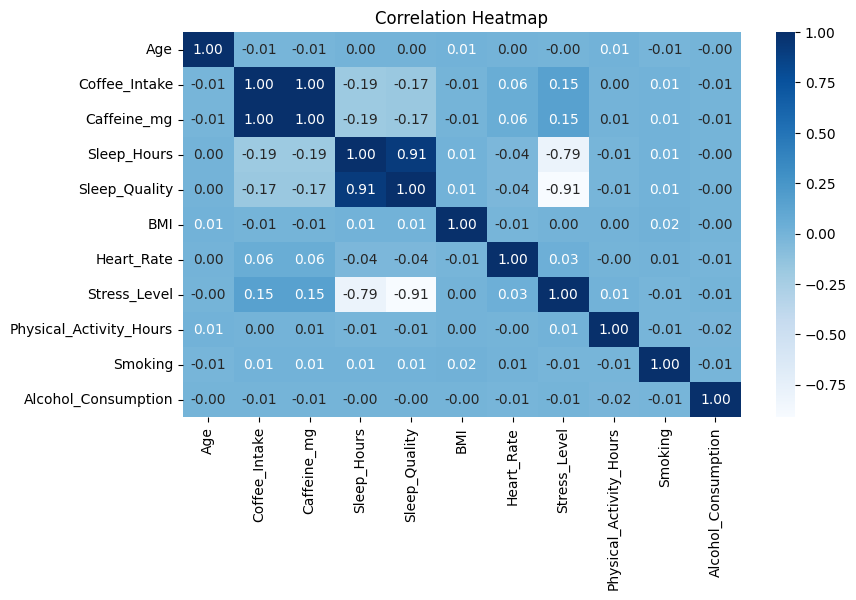

In [ ]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(9,5))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
X = df[['Stress_Level', 'Sleep_Hours']]
y = df['Sleep_Quality']

X_train, X_test, Y_train, Y_test = train_test_split(X,y, test_size=0.2, stratify=y,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def cal(model):
    model.fit(X_train_scaled, Y_train)
    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(Y_test, y_pred)
    classifications = classification_report(Y_test, y_pred)

    print(model)
    print("Accuracy is :", accuracy)
    print("classification report :\n",classifications)



In [ ]:
model1 = LogisticRegression(multi_class='multinomial')
model2=svm.LinearSVC(C=1)


In [ ]:
cal(model1)

LogisticRegression(multi_class='multinomial')
Accuracy is : 0.9907928388746803
classification report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       188
           1       1.00      1.00      1.00       401
           2       0.98      1.00      0.99      1101
           3       1.00      0.93      0.96       265

    accuracy                           0.99      1955
   macro avg       1.00      0.98      0.99      1955
weighted avg       0.99      0.99      0.99      1955



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
cal(model2)

LinearSVC(C=1)
Accuracy is : 0.9907928388746803
classification report :
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       188
           1       1.00      1.00      1.00       401
           2       0.98      1.00      0.99      1101
           3       1.00      0.93      0.96       265

    accuracy                           0.99      1955
   macro avg       1.00      0.98      0.99      1955
weighted avg       0.99      0.99      0.99      1955



#Unsupervised Learning
#K-Means Clustering

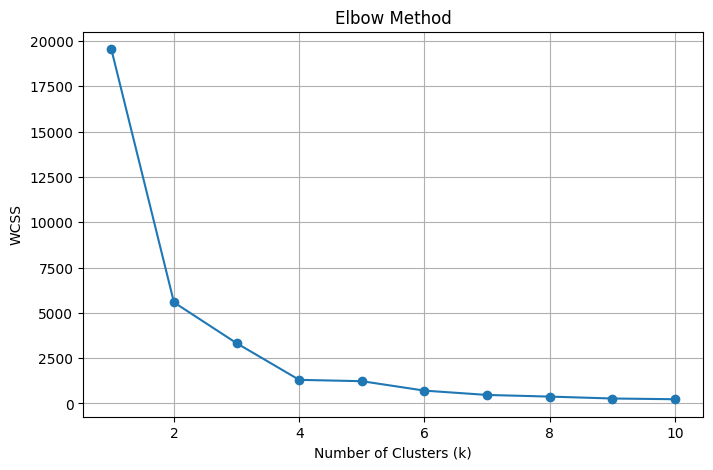

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


X = df[['Stress_Level', 'Sleep_Hours']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()